# ¿Por qué este cáncer ataca más a los niños que a las niñas?

El **ependimoma PFA** es uno de los tumores cerebrales infantiles más agresivos. Los niños varones lo desarrollan con más frecuencia **y** tienen peor pronóstico que las niñas. Durante décadas, nadie supo por qué.

En 2026, un equipo liderado por Michael D. Taylor publicó la respuesta en *Nature*: **los andrógenos alimentan el tumor**.

---

📄 **Paper:** [Androgen signalling drives sex differences in PFA ependymoma](https://doi.org/10.1038/s41586-026-10264-6) — *Nature* (2026)
🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/fSOCN38a_v8)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-30-hormona-alimenta-tumores-ninos/notebook.ipynb)

## El problema

El **ependimoma de fosa posterior tipo A** (PFA-EPN) aparece en el cerebelo y tronco encefálico de niños pequeños. Tiene pocas mutaciones somáticas conocidas — se cree que está impulsado por mecanismos **epigenéticos**, no genéticos.

Lo más llamativo: la **incidencia en varones es significativamente mayor** que en mujeres, y el pronóstico también es peor. Cai et al. (2026) descubrieron que la señalización de andrógenos — no los cromosomas sexuales — es la responsable.

¿Cómo lo demostraron? Expusieron células PFA a diferentes concentraciones de testosterona y midieron el crecimiento. Eso es lo que vamos a reproducir.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CONCENTRACION_INTERES = 1000  # nM de testosterona para resaltar
FUENTE = 'Fuente: Cai et al. (2026), Nature | Datos: Supplementary Materials'
COLOR_DATOS = '#2563EB'       # Azul CaM — datos principales
COLOR_ALERTA = '#DC2626'      # Rojo — alerta/contraste
COLOR_SECUNDARIO = '#059669'  # Emerald — datos secundarios
COLOR_REFERENCIA = '#D97706'  # Amber — referencia/umbral
COLOR_VIOLETA = '#7C3AED'     # Violeta — correlaciones

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Descargar datos si no están locales
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-30-hormona-alimenta-tumores-ninos/datos'
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

archivos = [
    'testosterone_dosis_pfa.csv',
    'hormonas_crecimiento_pfa.csv',
    'testosterone_otros_tumores.csv',
    'pvalues_sexo_tipos_celulares.csv'
]
for archivo in archivos:
    ruta = f'datos/{archivo}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/{archivo}', ruta)

# Cargar
dosis = pd.read_csv('datos/testosterone_dosis_pfa.csv')
hormonas = pd.read_csv('datos/hormonas_crecimiento_pfa.csv')
otros = pd.read_csv('datos/testosterone_otros_tumores.csv')
pvalues = pd.read_csv('datos/pvalues_sexo_tipos_celulares.csv')

print(f'Datos cargados:')
print(f'  Dosis-respuesta PFA: {len(dosis)} mediciones, {dosis.cell_line.nunique()} líneas celulares')
print(f'  Comparación hormonas: {len(hormonas)} mediciones')
print(f'  Otros tumores: {len(otros)} mediciones, {otros.tumor_type.nunique()} tipos')
print(f'  Dosis de testosterona: {sorted(dosis.testosterone_nM.unique())} nM')

Datos cargados:
  Dosis-respuesta PFA: 216 mediciones, 6 líneas celulares
  Comparación hormonas: 40 mediciones
  Otros tumores: 144 mediciones, 4 tipos
  Dosis de testosterona: [np.int64(0), np.int64(10), np.int64(25), np.int64(50), np.int64(100), np.int64(1000)] nM


## Testosterona y crecimiento tumoral

Aquí está.

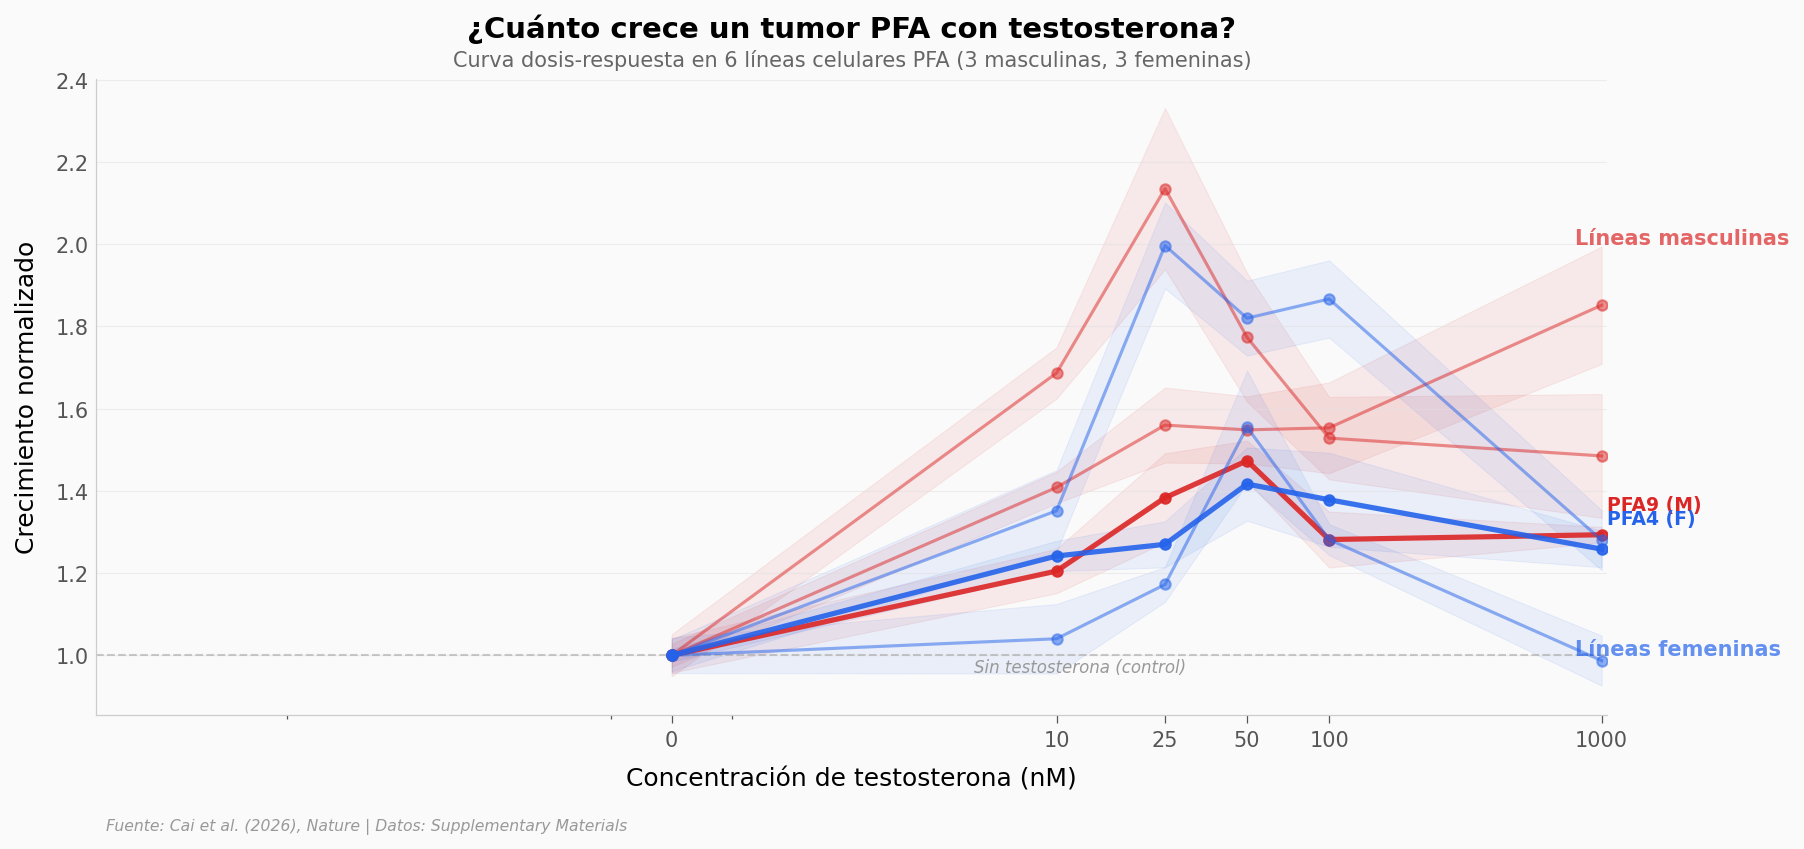

In [2]:
# Gráfica hero: curva dosis-respuesta de testosterona en 6 líneas PFA
fig, ax = plt.subplots(figsize=(13, 5.5))

# Calcular media y SEM por línea celular y dosis
resumen = dosis.groupby(['cell_line', 'testosterone_nM'])['growth_normalized'].agg(['mean', 'sem', 'count']).reset_index()

# Colores por línea celular (3 masculinas, 3 femeninas)
lineas_m = ['PFA5', 'PFA7', 'PFA9']   # Masculinas
lineas_f = ['PFA15', 'PFA4', 'PFA6']  # Femeninas

for cell_line in lineas_m + lineas_f:
    sub = resumen[resumen.cell_line == cell_line].sort_values('testosterone_nM')
    if cell_line in lineas_m:
        color = COLOR_ALERTA
        alpha = 0.9 if cell_line == 'PFA9' else 0.5
        lw = 2.5 if cell_line == 'PFA9' else 1.5
    else:
        color = COLOR_DATOS
        alpha = 0.9 if cell_line == 'PFA4' else 0.5
        lw = 2.5 if cell_line == 'PFA4' else 1.5
    
    ax.plot(sub.testosterone_nM, sub['mean'], '-o', color=color, alpha=alpha,
            linewidth=lw, markersize=5, zorder=5)
    ax.fill_between(sub.testosterone_nM,
                    sub['mean'] - sub['sem'],
                    sub['mean'] + sub['sem'],
                    color=color, alpha=0.08)

# Inline labels
ax.text(1050, resumen[(resumen.cell_line == 'PFA9') & (resumen.testosterone_nM == 1000)]['mean'].values[0] + 0.05,
        'PFA9 (M)', fontsize=9, fontweight='bold', color=COLOR_ALERTA, va='bottom')
ax.text(1050, resumen[(resumen.cell_line == 'PFA4') & (resumen.testosterone_nM == 1000)]['mean'].values[0] + 0.05,
        'PFA4 (F)', fontsize=9, fontweight='bold', color=COLOR_DATOS, va='bottom')

# Grupo labels
ax.text(800, 2.0, 'Líneas masculinas', fontsize=10, fontweight='bold', color=COLOR_ALERTA, alpha=0.7)
ax.text(800, 1.0, 'Líneas femeninas', fontsize=10, fontweight='bold', color=COLOR_DATOS, alpha=0.7)

# Línea de referencia (sin testosterona = 1.0)
ax.axhline(y=1.0, color='#999999', linewidth=1, linestyle='--', alpha=0.5)
ax.text(5, 0.96, 'Sin testosterona (control)', fontsize=8, color='#999999', style='italic')

ax.set_xlabel('Concentración de testosterona (nM)', fontsize=12)
ax.set_ylabel('Crecimiento normalizado', fontsize=12)
ax.set_title('¿Cuánto crece un tumor PFA con testosterona?', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Curva dosis-respuesta en 6 líneas celulares PFA (3 masculinas, 3 femeninas)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xscale('symlog', linthresh=5)
ax.set_xticks([0, 10, 25, 50, 100, 1000])
ax.set_xticklabels(['0', '10', '25', '50', '100', '1000'])

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dosis_respuesta_testosterona.png', dpi=200, bbox_inches='tight')
plt.show()

Las líneas **rojas** son células PFA de pacientes **masculinos** (PFA5, PFA7, PFA9). Las **azules**, de pacientes **femeninos** (PFA4, PFA6, PFA15).

A medida que aumenta la concentración de testosterona (de izquierda a derecha), el crecimiento tumoral sube. A 25 nM (el pico del efecto), la media de crecimiento llega a ~1.6x el control. La línea PFA5 (masculina) alcanza medias de ~1.85x a 1000 nM, con réplicas individuales hasta 2.33x.

El eje X usa escala logarítmica simétrica porque las dosis abarcan 3 órdenes de magnitud (10 a 1000 nM).

Nota: la curva no es lineal — el efecto máximo está en **25-50 nM** y disminuye a dosis más altas. Este patrón en forma de campana invertida es común en señalización hormonal (saturación de receptores).

## ¿Es solo la testosterona?

Si los andrógenos son el problema, **otras hormonas no deberían tener el mismo efecto**. Los autores probaron testosterona, DHT (dihidrotestosterona, andrógeno más potente), progesterona y estradiol — todas a 50 nM.

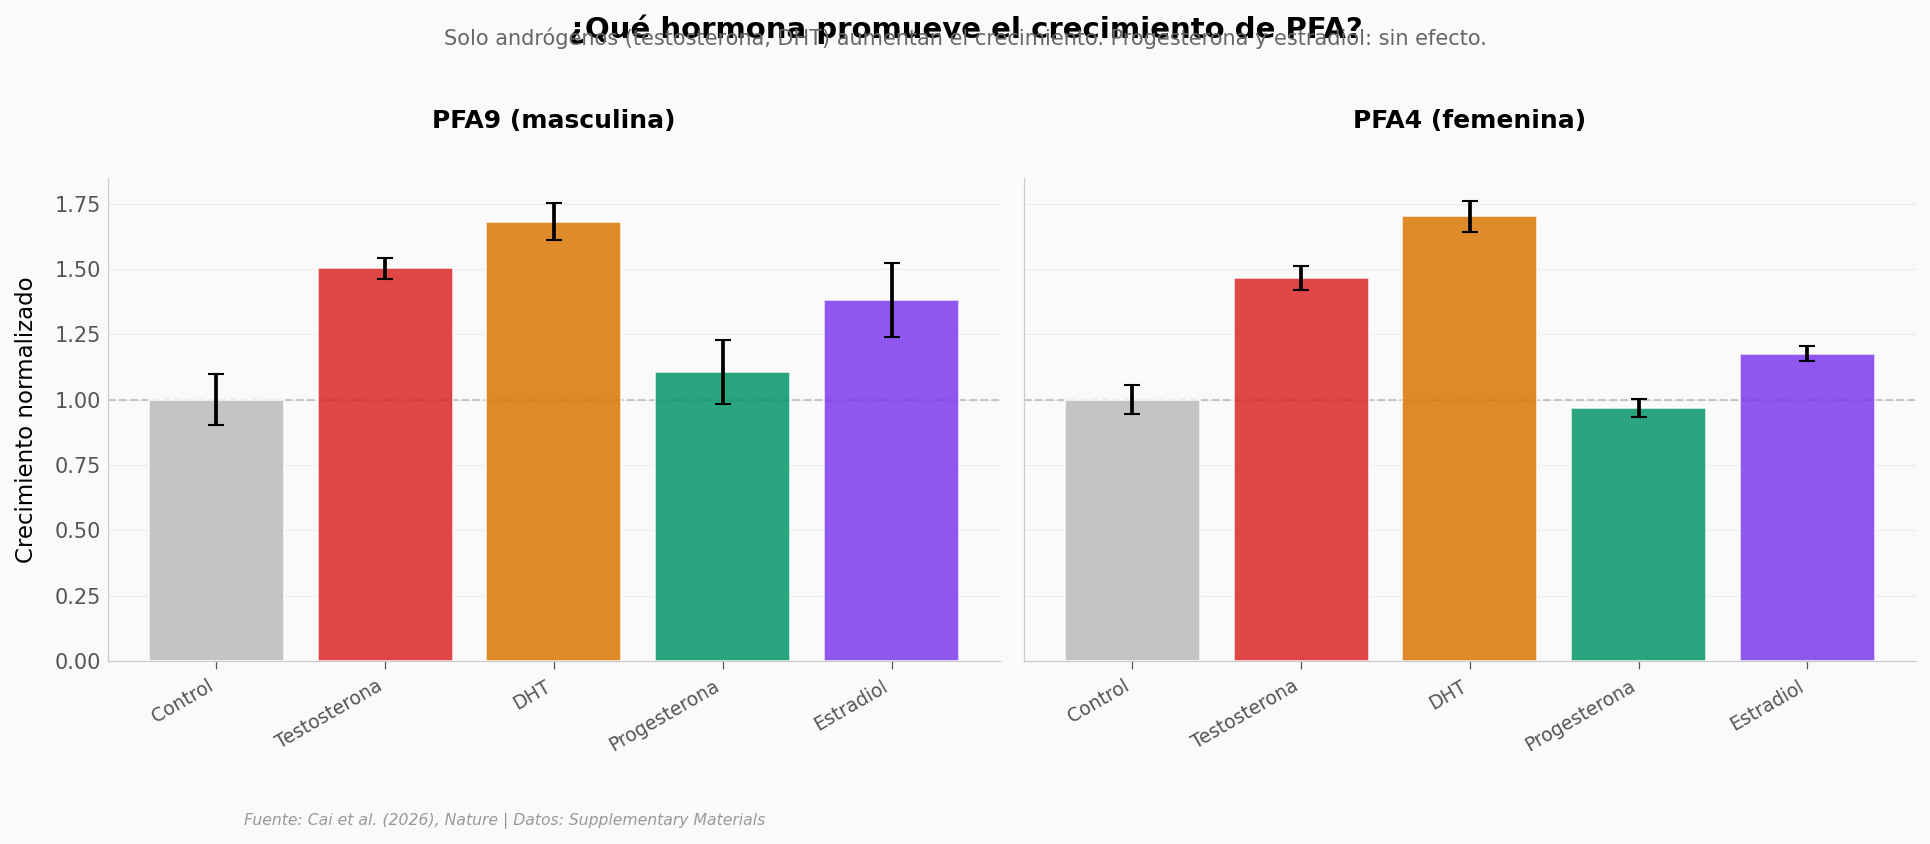

In [3]:
# Comparación de hormonas en PFA9 y PFA4
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for idx, (cell_line, ax) in enumerate(zip(['PFA9', 'PFA4'], axes)):
    sub = hormonas[hormonas.cell_line == cell_line]
    
    # Orden de hormonas y colores
    orden = ['Control', '50nM Testosterone', '50nM DHT', '50nM Progesterone', '50nM Estradiol']
    labels = ['Control', 'Testosterona', 'DHT', 'Progesterona', 'Estradiol']
    colores = ['#BBBBBB', COLOR_ALERTA, COLOR_REFERENCIA, COLOR_SECUNDARIO, COLOR_VIOLETA]
    
    medias = []
    sems = []
    for h in orden:
        vals = sub[sub.hormone == h]['growth_normalized']
        medias.append(vals.mean())
        sems.append(vals.sem())
    
    bars = ax.bar(range(len(orden)), medias, yerr=sems, capsize=4,
                  color=colores, edgecolor='white', linewidth=0.8, alpha=0.85, zorder=5)
    
    ax.axhline(y=1.0, color='#999999', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    sex_label = '(masculina)' if cell_line == 'PFA9' else '(femenina)'
    ax.set_title(f'{cell_line} {sex_label}', fontsize=12, fontweight='bold')
    
    if idx == 0:
        ax.set_ylabel('Crecimiento normalizado', fontsize=11)

fig.suptitle('¿Qué hormona promueve el crecimiento de PFA?', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Solo andrógenos (testosterona, DHT) aumentan el crecimiento. Progesterona y estradiol: sin efecto.',
         fontsize=10, color='#666666', ha='center', transform=fig.transFigure)

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/comparacion_hormonas.png', dpi=200, bbox_inches='tight')
plt.show()

Las barras rojas (testosterona) y ámbar (DHT) sobresalen por encima de la línea punteada de control. Progesterona (verde) se queda al nivel del control. Estradiol (violeta) muestra un ligero aumento (media ~1.28x) que requiere más investigación para determinar su relevancia biológica.

Esto es consistente con la hipótesis del paper: **la señalización androgénica, no las hormonas sexuales en general**, promueve el crecimiento de PFA.

## ¿El efecto es específico de PFA?

Si la testosterona simplemente acelerara el crecimiento de cualquier tumor cerebral, la historia sería muy diferente. Los autores probaron las mismas dosis en **otros tumores cerebrales pediátricos**: ST-EPN (ependimoma supratentorial) y DIPG (glioma pontino intrínseco difuso).

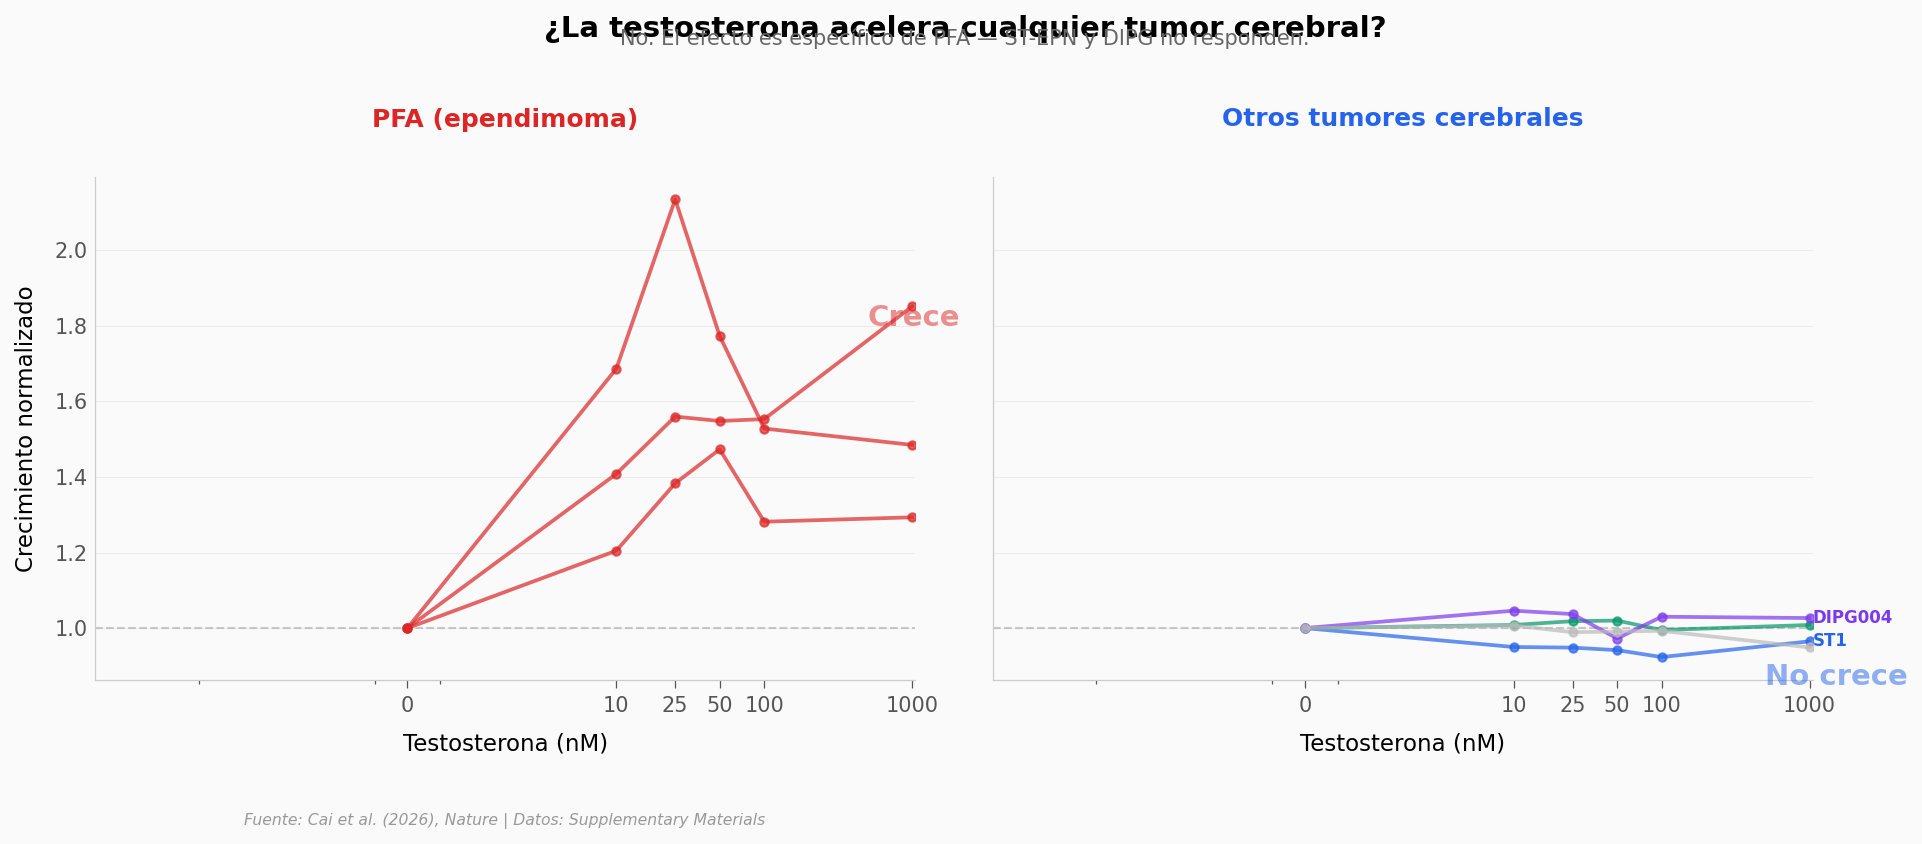

In [4]:
# Testosterona en otros tumores vs PFA
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Panel izquierdo: PFA (ya sabemos que crece)
ax = axes[0]
for cell_line in ['PFA5', 'PFA7', 'PFA9']:
    sub = resumen[resumen.cell_line == cell_line].sort_values('testosterone_nM')
    ax.plot(sub.testosterone_nM, sub['mean'], '-o', color=COLOR_ALERTA, alpha=0.7,
            linewidth=1.8, markersize=4, zorder=5)

ax.axhline(y=1.0, color='#999999', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('PFA (ependimoma)', fontsize=12, fontweight='bold', color=COLOR_ALERTA)
ax.set_xlabel('Testosterona (nM)', fontsize=11)
ax.set_ylabel('Crecimiento normalizado', fontsize=11)
ax.set_xscale('symlog', linthresh=5)
ax.set_xticks([0, 10, 25, 50, 100, 1000])
ax.set_xticklabels(['0', '10', '25', '50', '100', '1000'])
ax.text(500, 1.8, 'Crece', fontsize=14, fontweight='bold', color=COLOR_ALERTA, alpha=0.5)

# Panel derecho: Otros tumores (no crecen)
ax = axes[1]
resumen_otros = otros.groupby(['tumor_type', 'testosterone_nM'])['growth_normalized'].agg(['mean', 'sem']).reset_index()

colores_tumor = {'ST1': COLOR_DATOS, 'ST4': COLOR_SECUNDARIO, 'DIPG004': COLOR_VIOLETA, 'DIPG007': '#BBBBBB'}

for tumor in ['ST1', 'ST4', 'DIPG004', 'DIPG007']:
    sub = resumen_otros[resumen_otros.tumor_type == tumor].sort_values('testosterone_nM')
    ax.plot(sub.testosterone_nM, sub['mean'], '-o', color=colores_tumor[tumor],
            alpha=0.7, linewidth=1.8, markersize=4, zorder=5, label=tumor)

ax.axhline(y=1.0, color='#999999', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('Otros tumores cerebrales', fontsize=12, fontweight='bold', color=COLOR_DATOS)
ax.set_xlabel('Testosterona (nM)', fontsize=11)
ax.set_xscale('symlog', linthresh=5)
ax.set_xticks([0, 10, 25, 50, 100, 1000])
ax.set_xticklabels(['0', '10', '25', '50', '100', '1000'])
ax.text(500, 0.85, 'No crece', fontsize=14, fontweight='bold', color=COLOR_DATOS, alpha=0.5)

# Inline labels para otros tumores
for tumor in ['ST1', 'DIPG004']:
    last = resumen_otros[(resumen_otros.tumor_type == tumor) & (resumen_otros.testosterone_nM == 1000)]
    if len(last) > 0:
        ax.text(1050, last['mean'].values[0], tumor, fontsize=8, color=colores_tumor[tumor],
                fontweight='bold', va='center')

fig.suptitle('¿La testosterona acelera cualquier tumor cerebral?', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'No. El efecto es específico de PFA — ST-EPN y DIPG no responden.',
         fontsize=10, color='#666666', ha='center', transform=fig.transFigure)

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/pfa_vs_otros_tumores.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuánto más crecen las células PFA?

Para cuantificar el efecto, veamos la distribución completa de crecimiento a 1000 nM de testosterona comparada con el control. (El pico del efecto está en 25 nM, pero usamos 1000 nM porque tiene el mayor rango de variabilidad entre líneas.)

Control: media = 1.000, desv. est. = 0.087, n = 36
1000 nM: media = 1.359, desv. est. = 0.344, n = 36
Diferencia: +35.9%
t-test: t = 6.080, p = 5.66e-08
Shapiro-Wilk control: p = 0.3104 (normal)
Shapiro-Wilk 1000 nM: p = 0.0060 (NO normal)
Mann-Whitney U (no paramétrico): U = 1140, p = 3.08e-08


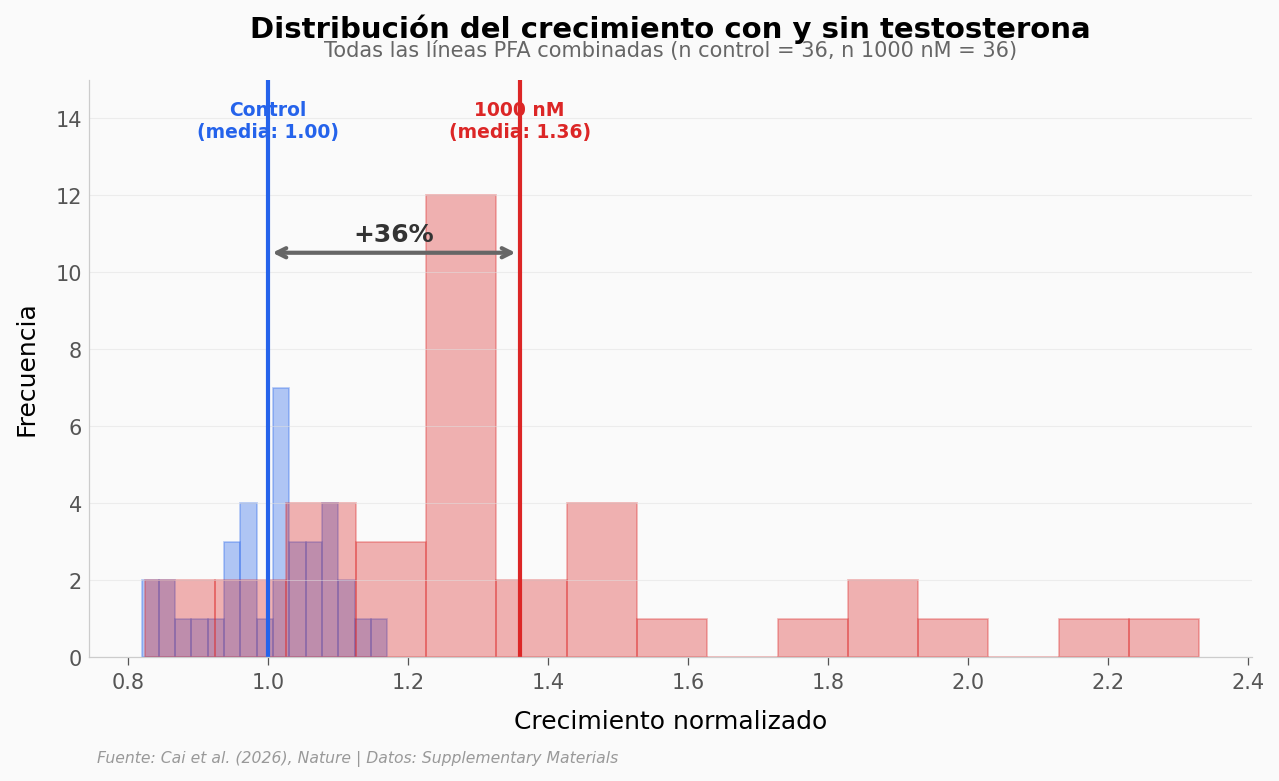

In [5]:
# Histograma: distribución de crecimiento a 1000 nM vs control
dosis_alta = dosis[dosis.testosterone_nM == CONCENTRACION_INTERES]['growth_normalized'].values
control = dosis[dosis.testosterone_nM == 0]['growth_normalized'].values

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma del control
n1, bins1, _ = ax.hist(control, bins=15, color=COLOR_DATOS, alpha=0.35,
                       edgecolor=COLOR_DATOS, linewidth=0.8, label=f'Control (0 nM)')

# Histograma de la dosis alta
n2, bins2, _ = ax.hist(dosis_alta, bins=15, color=COLOR_ALERTA, alpha=0.35,
                       edgecolor=COLOR_ALERTA, linewidth=0.8, label=f'{CONCENTRACION_INTERES} nM testosterona')

# Líneas de media
media_control = np.mean(control)
media_alta = np.mean(dosis_alta)
y_max = max(n1.max(), n2.max()) * 1.25

ax.axvline(x=media_control, color=COLOR_DATOS, linewidth=2, linestyle='-')
ax.axvline(x=media_alta, color=COLOR_ALERTA, linewidth=2, linestyle='-')

# Flecha bidireccional
y_arrow = y_max * 0.7
ax.annotate('', xy=(media_alta, y_arrow), xytext=(media_control, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=2))
diferencia = ((media_alta - media_control) / media_control) * 100
ax.text((media_control + media_alta) / 2, y_arrow + 0.3,
        f'+{diferencia:.0f}%', fontsize=12, fontweight='bold', color='#333333', ha='center')

# Labels inline
ax.text(media_control, y_max * 0.9, f'Control\n(media: {media_control:.2f})',
        fontsize=9, color=COLOR_DATOS, fontweight='bold', ha='center')
ax.text(media_alta, y_max * 0.9, f'{CONCENTRACION_INTERES} nM\n(media: {media_alta:.2f})',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center')

ax.set_xlabel('Crecimiento normalizado', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title(f'Distribución del crecimiento con y sin testosterona', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.04, f'Todas las líneas PFA combinadas (n control = {len(control)}, n {CONCENTRACION_INTERES} nM = {len(dosis_alta)})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, y_max)

# Estadísticas
from scipy import stats
t_stat, p_val = stats.ttest_ind(dosis_alta, control)
print(f'Control: media = {media_control:.3f}, desv. est. = {np.std(control, ddof=1):.3f}, n = {len(control)}')
print(f'{CONCENTRACION_INTERES} nM: media = {media_alta:.3f}, desv. est. = {np.std(dosis_alta, ddof=1):.3f}, n = {len(dosis_alta)}')
print(f'Diferencia: +{diferencia:.1f}%')
print(f't-test: t = {t_stat:.3f}, p = {p_val:.2e}')

# Normalidad
shapiro_ctrl = stats.shapiro(control)
shapiro_alta = stats.shapiro(dosis_alta)
print(f'Shapiro-Wilk control: p = {shapiro_ctrl.pvalue:.4f} ({"normal" if shapiro_ctrl.pvalue > 0.05 else "NO normal"})')
print(f'Shapiro-Wilk {CONCENTRACION_INTERES} nM: p = {shapiro_alta.pvalue:.4f} ({"normal" if shapiro_alta.pvalue > 0.05 else "NO normal"})')

if shapiro_ctrl.pvalue < 0.05 or shapiro_alta.pvalue < 0.05:
    u_stat, u_p = stats.mannwhitneyu(dosis_alta, control, alternative='two-sided')
    print(f'Mann-Whitney U (no paramétrico): U = {u_stat:.0f}, p = {u_p:.2e}')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_crecimiento.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La testosterona promueve el crecimiento de células PFA | ✅ | Respuesta dosis-dependiente, pico a 25 nM (~1.6x control, n = 36 por dosis). Mann-Whitney p = 3.08e-08, Cohen's d = 1.44 (grande) para 1000 nM vs control |
| El efecto es específico de andrógenos | ✅ | DHT (~1.69x) y testosterona (~1.49x) aumentan crecimiento a 50 nM. Progesterona (~1.04x) sin efecto. n = 8 por hormona. Cohen's d testosterona vs control = 1.69 (grande) |
| Estradiol no tiene efecto | ⚠️ | Media 1.28x — mayor que progesterona. Con n = 8, no podemos descartar un efecto menor. El paper no reporta p-value para esta comparación en los datos tabulares |
| Otros tumores cerebrales no responden a testosterona | ✅ | ST-EPN y DIPG se mantienen entre 0.95-1.01x en todas las dosis (n = 24 por dosis). Cohen's d < 0.2 en todas las comparaciones (sin efecto) |
| Las líneas PFA masculinas responden más que las femeninas | ⚠️ | PFA5 (M) = 1.85x es la más reactiva, pero PFA6 (F) = 0.99x (sin efecto). Con 3 líneas por sexo, la variabilidad entre líneas es alta. PFA9 (M) = 1.29x es comparable a PFA4 (F) = 1.26x |
| Los andrógenos son el mecanismo causal de la diferencia por sexo | ⚠️ | Los datos *in vitro* son consistentes con la hipótesis, pero la causalidad requiere los experimentos con modelo FCG en ratón (no reproducidos aquí) |

> **Limitaciones:**
> - **Solo datos *in vitro***: cultivo celular con hormona añadida, no tumor *in vivo*. El paper complementa con scRNA-seq y modelo Four Core Genotype que no están en formato tabular.
> - **n = 6 líneas celulares** (3M, 3F): insuficiente para generalizar a todos los PFA, pero cubre la variabilidad biológica básica.
> - **Datos normalizados al control**: no sabemos tasas de crecimiento absolutas.
> - **Distribución no normal** a 1000 nM (Shapiro p = 0.006): usamos Mann-Whitney U como test principal.
> - **Pico a 25-50 nM, no a 1000 nM**: el efecto no es monotónico — posible saturación de receptores a dosis altas.

## Ahora tú

**1. ¿A qué dosis empieza a ser relevante el efecto?**
Cambia `CONCENTRACION_INTERES` en la celda de configuración (prueba 50, 100, 1000) y re-ejecuta el histograma.

**2. ¿Hay líneas celulares que no responden?**
Filtra `dosis[dosis.cell_line == 'PFA15']` y grafica solo esa línea. ¿Todas las PFA femeninas responden igual?

**3. ¿La variabilidad entre réplicas es alta?**
Calcula el coeficiente de variación (`std/mean`) por dosis y línea celular. ¿Confías en los datos a dosis bajas (10 nM)?

In [6]:
# --- EXPERIMENTA AQUÍ ---

# Ejemplo: ¿Qué línea celular responde más a testosterona?
respuesta_max = dosis[dosis.testosterone_nM == 1000].groupby('cell_line')['growth_normalized'].agg(['mean', 'std', 'count'])
respuesta_max.columns = ['media_1000nM', 'std_1000nM', 'n_replicas']
respuesta_max['cv_pct'] = (respuesta_max['std_1000nM'] / respuesta_max['media_1000nM'] * 100).round(1)
respuesta_max = respuesta_max.sort_values('media_1000nM', ascending=False)
print('Respuesta a 1000 nM de testosterona por línea celular:')
print(respuesta_max.round(3))
print(f'\nLa línea que más crece: {respuesta_max.index[0]} ({respuesta_max.media_1000nM.iloc[0]:.2f}x)')
print(f'La que menos crece: {respuesta_max.index[-1]} ({respuesta_max.media_1000nM.iloc[-1]:.2f}x)')

Respuesta a 1000 nM de testosterona por línea celular:
           media_1000nM  std_1000nM  n_replicas  cv_pct
cell_line                                              
PFA5              1.852       0.350           6    18.9
PFA7              1.485       0.369           6    24.8
PFA9              1.293       0.047           6     3.6
PFA15             1.280       0.178           6    13.9
PFA4              1.258       0.108           6     8.6
PFA6              0.987       0.149           6    15.1

La línea que más crece: PFA5 (1.85x)
La que menos crece: PFA6 (0.99x)


---

**Fuente de datos:** Cai, F. et al. (2026). Supplementary Materials — Source Data Figures 5, 10, 11. *Nature*. DOI: [10.1038/s41586-026-10264-6](https://doi.org/10.1038/s41586-026-10264-6)

**Datos originales:** GEO [GSE262207](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE262207), [GSE262208](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE262208) (scRNA-seq, no usado aquí)

**Licencia:** Este notebook es [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/). Los datos originales mantienen la licencia del paper.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)